In [1]:
import os
import numpy as np
import pandas as pd
import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import os

base_dir = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"
for split in os.listdir(base_dir):
    split_path = os.path.join(base_dir, split)
    print(f"\n{split}/")
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        n_images = len(os.listdir(cls_path))
        print(f"   {cls}: {n_images} images")


Training/
   pituitary: 1400 images
   notumor: 1400 images
   meningioma: 1400 images
   glioma: 1400 images

Testing/
   pituitary: 400 images
   notumor: 400 images
   meningioma: 400 images
   glioma: 400 images


In [3]:
import pandas as pd

records = []
for split in ["Training", "Testing"]:
    split_path = os.path.join(base_dir, split)
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        for img_name in os.listdir(cls_path):
            records.append({"split": split, "class": cls, "filename": img_name,
                             "path": os.path.join(cls_path, img_name)})

df = pd.DataFrame(records)
print(df.shape)
df.head()

(7200, 4)


,split,class,filename,path
0,Training,pituitary,Tr-pi_124.jpg,/kaggle/input/datasets/masoudnickparvar/brain-...
1,Training,pituitary,Tr-pi_949.jpg,/kaggle/input/datasets/masoudnickparvar/brain-...
2,Training,pituitary,Tr-pi_786.jpg,/kaggle/input/datasets/masoudnickparvar/brain-...
3,Training,pituitary,Tr-pi_371.jpg,/kaggle/input/datasets/masoudnickparvar/brain-...
4,Training,pituitary,Tr-pi_599.jpg,/kaggle/input/datasets/masoudnickparvar/brain-...


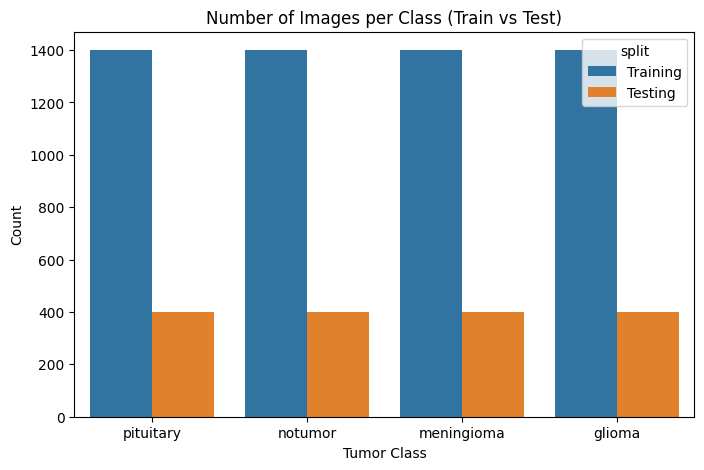

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="class", hue="split")
plt.title("Number of Images per Class (Train vs Test)")
plt.xlabel("Tumor Class")
plt.ylabel("Count")
plt.show()

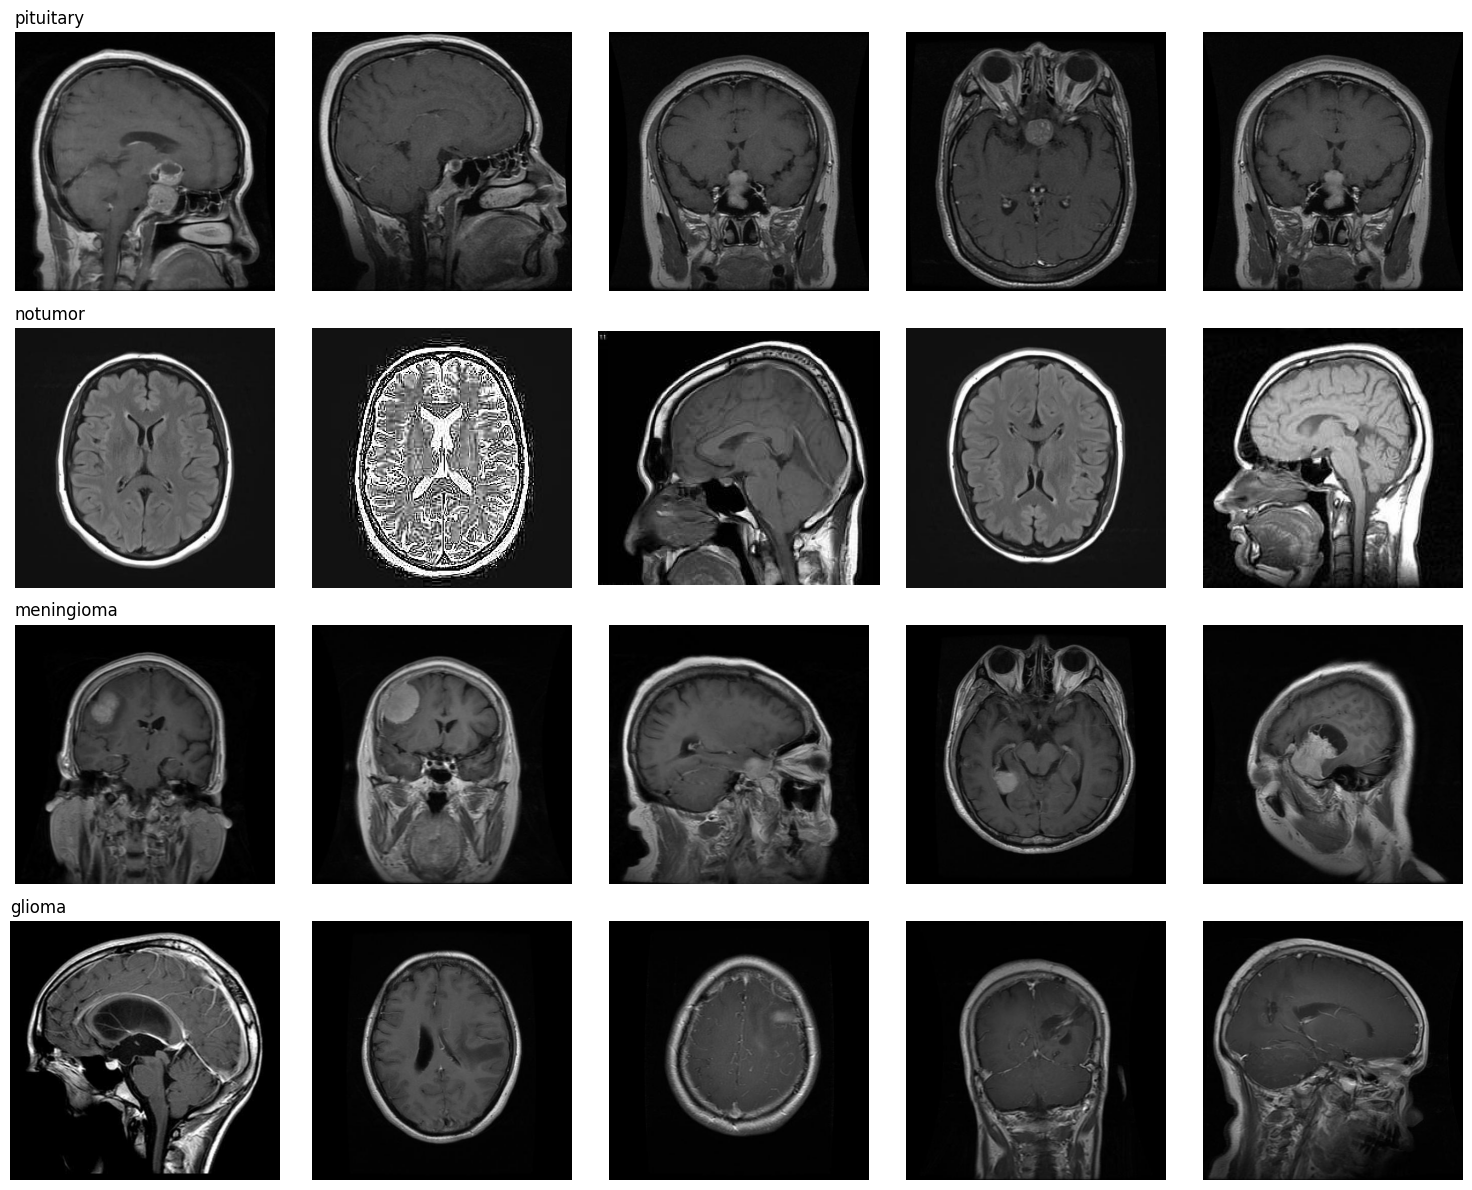

In [5]:
import cv2

classes = df["class"].unique()
fig, axes = plt.subplots(len(classes), 5, figsize=(15, 3*len(classes)))

for i, cls in enumerate(classes):
    sample_paths = df[df["class"] == cls]["path"].sample(5, random_state=42).values
    for j, path in enumerate(sample_paths):
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_ylabel(cls, fontsize=12)
    axes[i, 0].set_title(cls, fontsize=12, loc="left")

plt.tight_layout()
plt.show()

In [6]:
import random

sample_files = df["path"].sample(200, random_state=1).tolist()
widths, heights, channels = [], [], []

for path in sample_files:
    img = cv2.imread(path)
    h, w, c = img.shape
    heights.append(h)
    widths.append(w)
    channels.append(c)

size_df = pd.DataFrame({"width": widths, "height": heights, "channels": channels})
print(size_df.describe())
print("\nUnique channel counts:", size_df["channels"].unique())

            width      height  channels
count  200.000000  200.000000     200.0
mean   452.325000  452.585000       3.0
std    115.593289  114.628536       0.0
min    150.000000  168.000000       3.0
25%    438.500000  442.000000       3.0
50%    512.000000  512.000000       3.0
75%    512.000000  512.000000       3.0
max    680.000000  680.000000       3.0

Unique channel counts: [3]


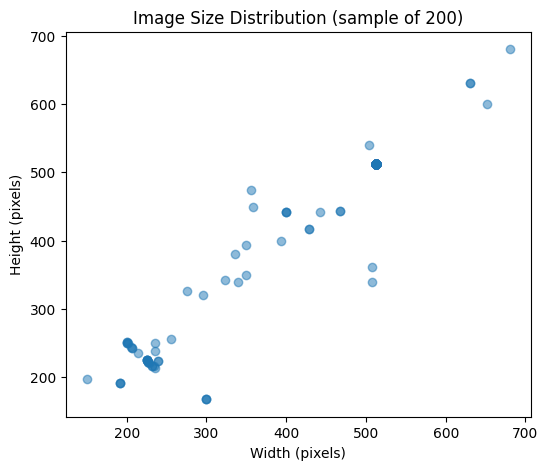

In [7]:
plt.figure(figsize=(6,5))
plt.scatter(size_df["width"], size_df["height"], alpha=0.5)
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.title("Image Size Distribution (sample of 200)")
plt.show()

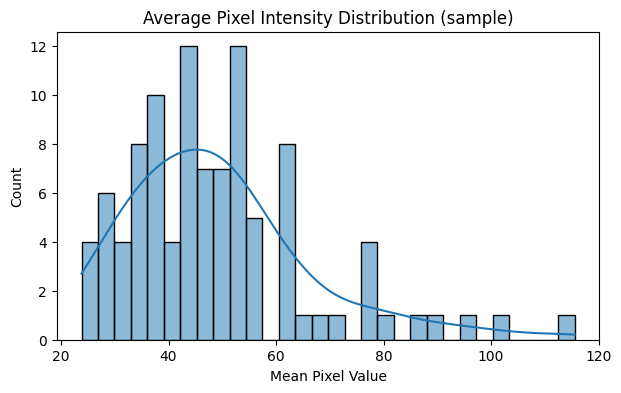

In [8]:
sample_gray = []
for path in sample_files[:100]:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    sample_gray.append(img.mean())

plt.figure(figsize=(7,4))
sns.histplot(sample_gray, bins=30, kde=True)
plt.title("Average Pixel Intensity Distribution (sample)")
plt.xlabel("Mean Pixel Value")
plt.show()

In [9]:
from PIL import Image

corrupted = []
for path in df["path"].sample(500, random_state=2):  # sample-check; loop full df if needed
    try:
        img = Image.open(path)
        img.verify()
    except Exception as e:
        corrupted.append(path)

print(f"Corrupted images found (in sample): {len(corrupted)}")

Corrupted images found (in sample): 0
